# Lab 10 — detekcja obiektów i segmentacja semantyczna

W tym laboratorium korzystamy z gotowych modeli z `torchvision`, ale samodzielnie implementujemy najważniejsze elementy ewaluacji:

1. pobranie obrazów i anotacji COCO,
2. wczytanie **ground truth** bounding boxów,
3. uruchomienie detektora obiektów,
4. policzenie **IoU** między predykcjami a anotacjami,
5. wykonanie greedy matchingu predykcji do ground truth,
6. policzenie **AP** przy zadanym progu IoU,
7. uruchomienie modelu segmentacji semantycznej,
9. policzenie prostych metryk segmentacji: IoU.

Notebook jest przygotowany z myślą o Google Colabie. Zalecane: `Runtime → Change runtime type → GPU`.



## 0. Importy i ustawienia

Nie trenujemy modeli od zera. Używamy pretrenowanych modeli:

- detekcja: Faster R-CNN MobileNetV3-FPN,
- segmentacja semantyczna: DeepLabV3 MobileNetV3.


In [129]:
from pathlib import Path
from collections import defaultdict
import json
import zipfile
import urllib.request

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torchvision
from torchvision.transforms import functional as F
from torchvision.utils import draw_bounding_boxes


print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


torch: 2.11.0+cu130
torchvision: 0.26.0+cu130
device: cpu


## 1. Pobranie przykładowych obrazów z COCO val2017

Użyjemy kilku obrazów z walidacyjnej części COCO 2017. Dzięki temu możemy pobrać oficjalne anotacje bounding boxów dla tych samych obrazów.


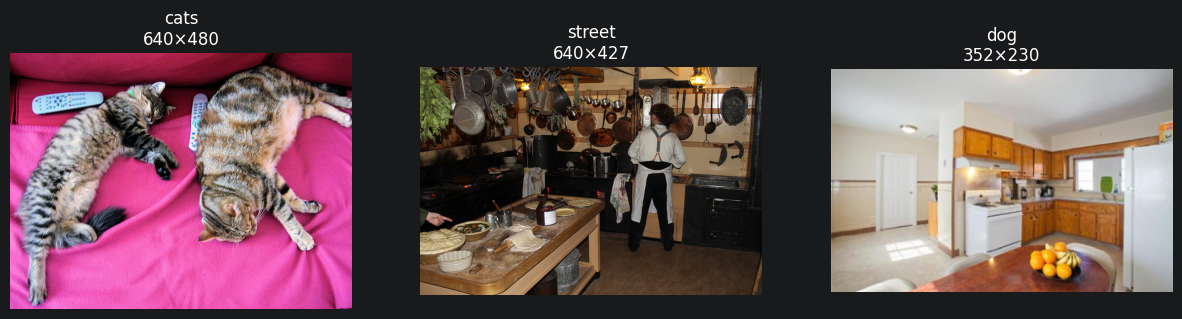

In [130]:
DATA_DIR = Path("lab10_data")
IMG_DIR = DATA_DIR / "images"
ANN_DIR = DATA_DIR / "annotations"
IMG_DIR.mkdir(parents=True, exist_ok=True)
ANN_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SPECS = {
    "cats": {"image_id": 39769, "file_name": "000000039769.jpg"},
    "street": {"image_id": 397133, "file_name": "000000397133.jpg"},
    "dog": {"image_id": 37777, "file_name": "000000037777.jpg"},
}

COCO_VAL_URL = "http://images.cocodataset.org/val2017"

def download_file(url, path):
    path = Path(path)
    if path.exists():
        return path
    print("Downloading", url)
    urllib.request.urlretrieve(url, path)
    return path

images = {}
for name, spec in IMAGE_SPECS.items():
    url = f"{COCO_VAL_URL}/{spec['file_name']}"
    path = IMG_DIR / spec["file_name"]
    download_file(url, path)
    images[name] = Image.open(path).convert("RGB")

fig, axes = plt.subplots(1, len(images), figsize=(15, 5))
for ax, (name, img) in zip(axes, images.items()):
    ax.imshow(img)
    ax.set_title(f"{name}\n{img.size[0]}×{img.size[1]}")
    ax.axis("off")
plt.show()


## 2. Pobranie ground truth bounding boxów z COCO

Plik `instances_val2017.json` zawiera anotacje detekcyjne dla obrazów walidacyjnych COCO.

Ważne: COCO zapisuje bounding box jako:

```python
[x_min, y_min, width, height]
```

W większości funkcji w tym notebooku będziemy używać formatu:

```python
[x_min, y_min, x_max, y_max]
```


In [131]:
ANN_ZIP_URL = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"
ANN_ZIP_PATH = ANN_DIR / "annotations_trainval2017.zip"
ANN_JSON_PATH = ANN_DIR / "annotations" / "instances_val2017.json"

if not ANN_JSON_PATH.exists():
    download_file(ANN_ZIP_URL, ANN_ZIP_PATH)
    with zipfile.ZipFile(ANN_ZIP_PATH, "r") as zf:
        zf.extract("annotations/instances_val2017.json", ANN_DIR)

with open(ANN_JSON_PATH, "r") as f:
    coco = json.load(f)

print("Liczba obrazów w anotacjach:", len(coco["images"]))
print("Liczba anotacji:", len(coco["annotations"]))
print("Liczba kategorii:", len(coco["categories"]))


Liczba obrazów w anotacjach: 5000
Liczba anotacji: 36781
Liczba kategorii: 80


In [132]:
coco_categories = {cat["id"]: cat["name"] for cat in coco["categories"]}
selected_image_ids = {spec["image_id"] for spec in IMAGE_SPECS.values()}

annotations_by_image_id = defaultdict(list)
for ann in coco["annotations"]:
    if ann["image_id"] in selected_image_ids and ann.get("iscrowd", 0) == 0:
        annotations_by_image_id[ann["image_id"]].append(ann)

def coco_xywh_to_xyxy(box):
    """Konwersja COCO [x, y, w, h] -> [x_min, y_min, x_max, y_max]."""
    x, y, w, h = box
    return [x, y, x + w, y + h]

def load_ground_truth_for_images(image_specs):
    ground_truths = {}
    for name, spec in image_specs.items():
        anns = annotations_by_image_id[spec["image_id"]]
        boxes = [coco_xywh_to_xyxy(ann["bbox"]) for ann in anns]
        labels = [ann["category_id"] for ann in anns]
        ground_truths[name] = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64),
        }
    return ground_truths

ground_truths = load_ground_truth_for_images(IMAGE_SPECS)

for name, gt in ground_truths.items():
    label_names = [coco_categories[int(label)] for label in gt["labels"]]
    print(f"{name}: {len(gt['boxes'])} obiektów")
    print(label_names)


cats: 6 obiektów
['remote', 'remote', 'couch', 'bed', 'cat', 'cat']
street: 19 obiektów
['bottle', 'dining table', 'person', 'knife', 'bowl', 'bowl', 'oven', 'person', 'cup', 'cup', 'bowl', 'bowl', 'broccoli', 'spoon', 'broccoli', 'broccoli', 'oven', 'carrot', 'sink']
dog: 14 obiektów
['potted plant', 'chair', 'chair', 'dining table', 'refrigerator', 'banana', 'oven', 'sink', 'orange', 'orange', 'orange', 'orange', 'chair', 'orange']


### Wizualizacja ground truth


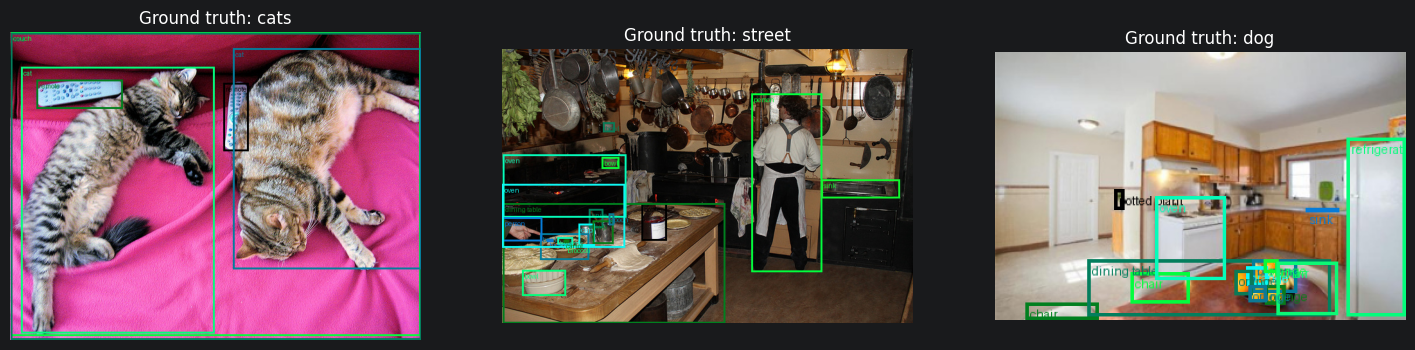

In [133]:
def image_to_uint8_tensor(img):
    return F.pil_to_tensor(img)

def label_names_from_ids(labels, categories):
    return [categories.get(int(label), str(int(label))) for label in labels]

def draw_boxes(img, boxes, labels, categories, width=3):
    image_tensor = image_to_uint8_tensor(img)
    label_texts = label_names_from_ids(labels, categories)
    if len(boxes) == 0:
        return img
    drawn = draw_bounding_boxes(
        image_tensor,
        boxes=boxes,
        labels=label_texts,
        width=width,
    )
    return F.to_pil_image(drawn)

fig, axes = plt.subplots(1, len(images), figsize=(18, 6))
for ax, (name, img) in zip(axes, images.items()):
    gt = ground_truths[name]
    ax.imshow(draw_boxes(img, gt["boxes"], gt["labels"], coco_categories))
    ax.set_title(f"Ground truth: {name}")
    ax.axis("off")
plt.show()


## 3. Zadanie 1. Detekcja obiektów modelem Faster R-CNN (5 pkt)

Dokonaj detekcji na każdym z obrazów testowych i wyświetl wyniki w postaci bboxów.


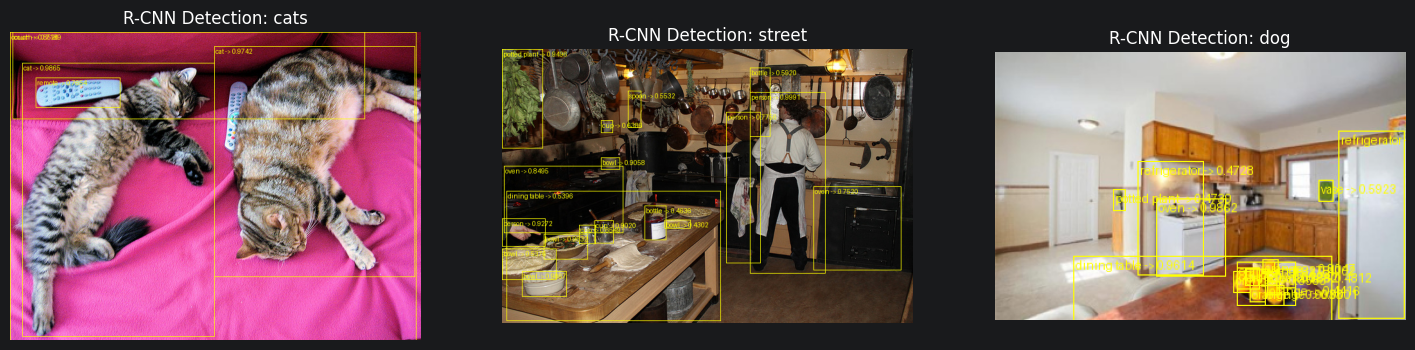

In [134]:
from torchvision.models.detection import (
    fasterrcnn_mobilenet_v3_large_fpn,
    FasterRCNN_MobileNet_V3_Large_FPN_Weights,
)

weights = FasterRCNN_MobileNet_V3_Large_FPN_Weights.DEFAULT
model = fasterrcnn_mobilenet_v3_large_fpn(pretrained=True, weights=weights)

model.eval()

pprocess = weights.transforms()
categories = weights.meta['categories']

figure, axes = plt.subplots(1, len(images), figsize=(18, 6))

for ax, (name, img) in zip(axes, images.items()):
    tensor = pprocess(img)
    with torch.no_grad():
        pred = model([tensor])[0]

    thresh = 0.4
    mask = pred['scores'] > thresh
    boxes = pred['boxes'][mask]
    labels = pred['labels'][mask]
    scores = pred['scores'][mask]

    label_text = [f"{categories[label]} -> {score:.4f}" for label, score in zip(labels, scores)]

    uint8_img = F.pil_to_tensor(img)

    if len(boxes) > 0:
        box = draw_bounding_boxes(uint8_img, boxes, labels = label_text, colors = "yellow")
    else:
        box = uint8_img

    ax.imshow(F.to_pil_image(box))
    ax.set_title(f"R-CNN Detection: {name}")
    ax.axis("off")


## Zadanie 2. Funkcje do liczenia IoU między detekcjami a ground truth (10 pkt)

Zaimplementuj funkcję `box_iou`, która liczy **intersection over union** dla dwóch ramek w formacie:

```python
[x_min, y_min, x_max, y_max]
```

Następnie użyj jej w funkcji `iou_matrix`, która policzy macierz IoU między wszystkimi predykcjami i wszystkimi ramkami ground truth dla wybranego obrazu.


In [135]:
def box_iou(box_a, box_b):
    """
    box_a, box_b: Tensor/list o długości 4 w formacie [x_min, y_min, x_max, y_max]
    Zwraca IoU jednej pary ramek.
    """
    # TODO:
    # 1. policz współrzędne przecięcia,
    # 2. policz pole przecięcia,
    # 3. policz pola obu ramek,
    # 4. policz union,
    # 5. zwróć intersection / union.

    x_min = max(box_a[0], box_b[0])
    y_min = max(box_a[1], box_b[1])

    x_max = min(box_a[2], box_b[2])
    y_max = min(box_a[3], box_b[3])

    width = max(0, x_max - x_min)
    height = max(0, y_max - y_min)

    intersection = width * height

    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])

    union = area_a + area_b - intersection

    iou = float(intersection) / float(union)

    return iou


In [136]:
def iou_matrix(pred_boxes, gt_boxes):
    """
    pred_boxes: Tensor[N, 4]
    gt_boxes: Tensor[M, 4]
    Zwraca macierz Tensor[N, M], gdzie element [i, j] to IoU predykcji i z ground truth j.
    """
    # TODO: utwórz macierz zer i wypełnij ją wartościami box_iou dla każdej pary ramek.

    matrix_0 = np.zeros([pred_boxes.shape[0], gt_boxes.shape[0]])

    for i in  range (pred_boxes.shape[0]):
        for j in range (gt_boxes.shape[0]):
            matrix_0[i, j] = box_iou(pred_boxes[i], gt_boxes[j])

    return matrix_0


### Zadanie 3. Wyznaczenie IoU dla prawdziwych predykcji i ground truth oraz wizualizacja (5 pkt)

Dla przejrzystości w tej sekcji używamy predykcji o `score >= 0.5`. Wyrysuj na zdjęciach tylko te detekcje, dla których IOU z ground truth było wyższe od progu ```0.5```.

In [137]:
selected_image = "dog"  # zmień na: "street" albo "dog"
score_threshold = 0.5

# TODO: Twoj kod tutaj

img = images[selected_image]
gt_boxes = ground_truths[selected_image]['boxes']

tensor = pprocess(img)

with torch.no_grad():
    pred = model([tensor])[0]

boxes_no_filter = pred['boxes']
matrix_iou_no_filter = iou_matrix(boxes_no_filter, gt_boxes)

mask = pred['scores'] > score_threshold
boxes = pred['boxes'][mask]
matrix_iou = iou_matrix(boxes, gt_boxes)

print(f"Selected image: {selected_image}")
print(f"Number of predictions before filtering: {len(matrix_iou_no_filter)}")
print(f"Number of predictions after filtering: {len(matrix_iou)}")
print(f"Number of true Ground Truth objects: {len(gt_boxes)}\n")
print(f"Filtered matrix:\n{np.array2string(matrix_iou, precision=4, suppress_small=True)}")


Selected image: dog
Number of predictions before filtering: 67
Number of predictions after filtering: 11
Number of true Ground Truth objects: 14

Filtered matrix:
[[0.     0.     0.     0.     0.8147 0.     0.     0.     0.     0.
  0.     0.     0.     0.    ]
 [0.     0.     0.0181 0.0665 0.     0.     0.922  0.     0.     0.
  0.     0.     0.     0.    ]
 [0.     0.0236 0.1049 0.8349 0.     0.0869 0.0796 0.     0.0227 0.0219
  0.0106 0.0261 0.1698 0.0157]
 [0.     0.     0.     0.018  0.     0.0561 0.     0.     0.0084 0.
  0.     0.0297 0.     0.8665]
 [0.     0.     0.     0.0268 0.     0.0845 0.     0.     0.0018 0.8575
  0.     0.     0.036  0.0153]
 [0.     0.     0.     0.0243 0.     0.     0.     0.     0.0586 0.
  0.     0.7024 0.     0.0046]
 [0.     0.     0.     0.1794 0.     0.4992 0.     0.     0.1514 0.146
  0.0527 0.1403 0.1597 0.1048]
 [0.     0.     0.     0.016  0.     0.1542 0.     0.     0.0562 0.
  0.7045 0.     0.0035 0.    ]
 [0.     0.     0.     0.0266 0.  

## Zadanie 4. Matching do wyznaczenia AP (15 pkt)

W detekcji samo `score` nie mówi jeszcze, czy predykcja jest poprawna. Predykcja jest uznawana za **true positive**, jeżeli:

1. ma tę samą klasę co obiekt ground truth,
2. jej IoU z tym obiektem jest co najmniej równe zadanemu progowi, np. `0.5`,
3. **dany obiekt ground truth nie został już wcześniej dopasowany do predykcji o wyższym score.**

Zaimplementujemy greedy matching dla jednej klasy, a potem użyjemy go do policzenia AP. Dla uproszczenia działamy na jednym zdjęciu.


In [138]:
def match_predictions_for_class(predictions, ground_truths, class_id, iou_threshold=0.5):
    """
    predictions: lista słowników:
        {"box": box, "label": label, "score": score}

    ground_truths: lista słowników:
        {"box": box, "label": label}

    class_id: klasa, dla której liczymy matching
    iou_threshold: minimalne IoU wymagane do uznania predykcji za TP

    Zwraca:
        tp: lista 0/1 dla kolejnych predykcji posortowanych po score
        fp: lista 0/1 dla kolejnych predykcji posortowanych po score
        num_gt: liczba obiektów ground truth danej klasy
    """

    # TODO:
    # wybierz tylko predykcje klasy class_id
    # wybierz tylko obiekty ground truth klasy class_id
    # posortuj predykcje malejąco po score
    # przygotuj zbiór indeksów już dopasowanych obiektów GT
    # przygotuj listy tp i fp
    # dla każdej predykcji znajdź niedopasowany GT o największym IoU
    # jeśli najlepsze IoU >= iou_threshold, dodaj TP;
    # w przeciwnym razie dodaj FP
    # zwróć tp, fp oraz liczbę obiektów GT tej klasy

    preds = [pred for pred in predictions if pred['label'] == class_id]
    gts = [gt for gt in ground_truths if gt['label'] == class_id]

    preds.sort(key=lambda x: x['score'], reverse=True)

    matched_gts = set()
    tp = []
    fp = []

    for pred in preds:
        best_iou = 0
        best_gt = -1

        for i, gt in enumerate(gts):
            if i in matched_gts:
                continue

            iou = box_iou(pred["box"], gt["box"])

            if iou > best_iou:
                best_iou = iou
                best_gt = i

        if best_iou >= iou_threshold and best_gt != -1:
            tp.append(1)
            fp.append(0)
            matched_gts.add(best_gt)
        else:
            tp.append(0)
            fp.append(1)
    return tp, fp, len(gts)

def average_precision(tp, fp, num_gt):
    """
    tp: lista 0/1 informująca, które predykcje są true positive
    fp: lista 0/1 informująca, które predykcje są false positive
    num_gt: liczba obiektów ground truth danej klasy

    Zwraca:
        ap: average precision dla jednej klasy
    """

    # TODO:
    # policz skumulowane TP i FP
    # policz precision dla kolejnych predykcji
    # policz recall dla kolejnych predykcji
    # policz pole pod krzywą precision-recall
    # zwróć AP jako float

    if num_gt == 0 or len(tp) == 0:
        return 0

    tp_cumsum = np.cumsum(tp)
    fp_cumsum = np.cumsum(fp)

    recalls = tp_cumsum / num_gt
    precisions = tp_cumsum / (tp_cumsum + fp_cumsum)

    recalls = np.concatenate(([0], recalls))
    precisions = np.concatenate(([1], precisions))

    ap = 0

    for i in range(1, len(recalls)):
        ap += (recalls[i] - recalls[i - 1]) * precisions[i]

    return float(ap)

# TODO: policz dla dowolnych 3 klas z wybranych przykładowych obrazów

classes_to_test = [17, 18, 3] # cat, dog, car

all_predictions = []
all_ground_truths = []

img = images[selected_image]
img_tensor = pprocess(img)
gt = ground_truths[selected_image]

for i in range(len(gt["boxes"])):
    all_ground_truths.append({
        "box": gt["boxes"][i].tolist(),
        "label": gt["labels"][i].item()
    })

with torch.no_grad():
    pred = model([img_tensor])[0]

for i in range(len(pred["boxes"])):
    if pred["scores"][i] > 0.5:
        all_predictions.append({
            "box": pred["boxes"][i].tolist(),
            "label": pred["labels"][i].item(),
            "score": pred["scores"][i].item()
        })

print(f"Average Precision for: '{selected_image}' image")
for class_id in classes_to_test:
    tp, fp, num_gt = match_predictions_for_class(all_predictions, all_ground_truths, class_id)
    ap = average_precision(tp, fp, num_gt)

    class_name = coco_categories.get(class_id, str(class_id))
    print(f"Class: {class_name} | AP: {ap:.4f} | Number of objects: {num_gt}")



Average Precision for: 'dog' image
Class: cat | AP: 0.0000 | Number of objects: 0
Class: dog | AP: 0.0000 | Number of objects: 0
Class: car | AP: 0.0000 | Number of objects: 0


## Zadanie 5. Segmentacja semantyczna modelem DeepLabV3 (10 pkt)

W segmentacji semantycznej model przypisuje klasę do każdego piksela.

Uruchom model dla 3 przykładowych obrazów i zwizualizuj maski w postaci map kolorów. Napisz funkcje pomocnicze jeśli są konieczne.


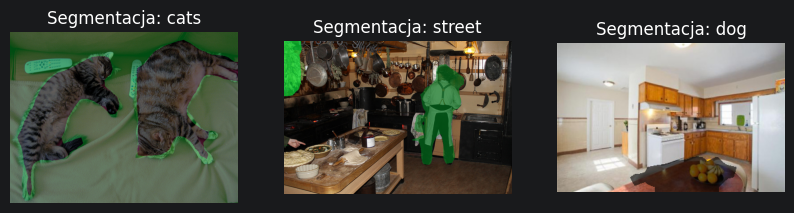

In [139]:
from torchvision.utils import draw_segmentation_masks
from torchvision.models.segmentation import (
    deeplabv3_mobilenet_v3_large,
    DeepLabV3_MobileNet_V3_Large_Weights,
)

# TODO: uruchomienie i wizualizacja tutaj

weights = DeepLabV3_MobileNet_V3_Large_Weights.DEFAULT
model = deeplabv3_mobilenet_v3_large(pretrained=True, weights=weights)
model.eval()

fig, axes = plt.subplots(1, len(images), figsize=(10, 10))

for ax, (name, img) in zip(axes, images.items()):
    img_uint8 = F.pil_to_tensor(img)

    img_float = F.convert_image_dtype(img_uint8)

    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]

    img_normalized = F.normalize(img_float, mean=mean, std=std)
    batch = img_normalized.unsqueeze(0)

    with torch.no_grad():
        output = model(batch)['out'][0]

    predicted_pixels = output.argmax(0)

    unique_classes = predicted_pixels.unique()
    unique_classes = unique_classes[unique_classes != 0]

    if len(unique_classes) > 0:
        masks_list = [predicted_pixels == cls_id for cls_id in unique_classes]
        masks_tensor = torch.stack(masks_list)

        res_img = draw_segmentation_masks(img_uint8, masks=masks_tensor, alpha=0.6)
    else:
        res_img = img_uint8

    ax.imshow(F.to_pil_image(res_img))
    ax.set_title(f"Segmentacja: {name}")
    ax.axis("off")

plt.show()



## Zadanie 6. Maska binarna jednej klasy (5 pkt)

Zaimplementuj funkcję, która dla mapy klas zwraca maskę binarną pikseli należących do podanej klasy.

Funkcja powinna przyjmować mapę klas i nazwę klasy, dla której chcemy uzyskać odfiltrowaną maskę.

Zwizualizuj wyniki.


In [140]:
# TODO: Twój kod tutaj

## Zadanie 7. Porównanie jakości segmentacji jednej klasy z maskami GT (15 pkt)

W poprzednim zadaniu wyznaczono binarną maskę predykcji dla jednej klasy, np. cat.

Teraz należy zbudować binarną maskę ground truth na podstawie masek instancji COCO i porównać ją z predykcją modelu segmentacyjnego. Poniżej przykład i wizualizacja maski GT:

loading annotations into memory...
Done (t=0.19s)
creating index...
index created!


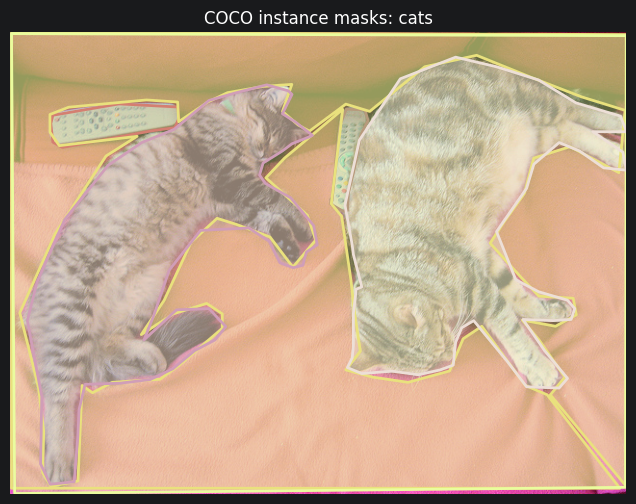

In [141]:
# Minimalna wizualizacja masek instancji COCO dla obrazu "cats"

!pip install -q pycocotools

import urllib.request
import zipfile
import shutil
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pycocotools.coco import COCO

# Pobranie pliku z adnotacjami instancji COCO, jeśli go jeszcze nie ma
ann_path = ANN_DIR / "instances_val2017.json"
ann_zip_path = DATA_DIR / "annotations_trainval2017.zip"

if not ann_path.exists():
    ann_url = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"
    urllib.request.urlretrieve(ann_url, ann_zip_path)

    with zipfile.ZipFile(ann_zip_path, "r") as zf:
        with zf.open("annotations/instances_val2017.json") as src:
            with open(ann_path, "wb") as dst:
                shutil.copyfileobj(src, dst)

# Obraz cats
image_key = "cats"
image_id = IMAGE_SPECS[image_key]["image_id"]
image_path = IMG_DIR / IMAGE_SPECS[image_key]["file_name"]

coco = COCO(str(ann_path))

image = Image.open(image_path).convert("RGB")
image_np = np.array(image)

# Wszystkie maski instancji dla tego obrazu
ann_ids = coco.getAnnIds(imgIds=[image_id])
anns = coco.loadAnns(ann_ids)

plt.figure(figsize=(8, 6))
plt.imshow(image_np)
coco.showAnns(anns)
plt.axis("off")
plt.title("COCO instance masks: cats")
plt.show()

###Co należy zrobić?

- Wybrać wszystkie instancje COCO danej klasy na obrazie.
- Połączyć ich maski w jedną binarną maskę ground truth.
- Porównać maskę predykcji z maską GT.
- Policzyć: IoU

In [142]:
# TODO: Zad 7.

### Skala ocen:

15 pkt - dst, 25 pkt - dst+, 35 pkt - db, 45 pkt - db+, 55 pkt - bdb